# Etapa 03 — ¿Qué actores, recursos y contratos cambian la decisión?

Consulta el dossier. Predice, calcula, explica y juzga el alcance antes de registrar tu decisión.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
# Encuentra la raíz tanto desde la carpeta del notebook como desde la raíz del libro.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'sa_mise' / '__init__.py').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from sa_mise import datos, modelos, expediente
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})

In [2]:
from sa_mise import sector
CASO='ejemplo_docente'
# Usa el mismo identificador de tu equipo en las ocho etapas.

## 1. Conservar el universo observado
El máximo horario observado se mantiene con ese nombre. No se usa como CEN. Los recursos sin clasificación permanecen en el total.

In [3]:
recursos=datos.proxies_recursos()
resumen_recursos=recursos.groupby('Type',dropna=False).agg(recursos=('Type','size'),produccion_2024_GWh=('produccion_2024_GWh','sum'))
display(resumen_recursos)
assert np.isclose(resumen_recursos.produccion_2024_GWh.sum(),recursos.produccion_2024_GWh.sum())

,recursos,produccion_2024_GWh
Type,,
COGENERADOR,12,835.587559
EOLICA,2,148.792042
HIDRAULICA,153,54494.304158
SIN_CLASIFICAR,9,45.176936
SOLAR,121,3297.222047
TERMICA,67,24441.840422


La suma conserva filas y energía del archivo. Esto no prueba que el universo sea completo. Antes de calcular participaciones nacionales hay que conciliar cobertura y definición con el total correspondiente.

## 2. Tres ponderaciones, tres preguntas
El perfil solar es una forma sintética idéntica cada día. Se aplica a los precios horarios medios de 2024, sin alterar esos precios. No es la generación observada de una planta.

dias                                          366.000000
precio_medio_nominal_COP_kWh                  676.076197
precio_ponderado_demanda_comercial_COP_kWh    686.192565
captura_con_perfil_solar_sintetico_COP_kWh    680.016324
dtype: float64

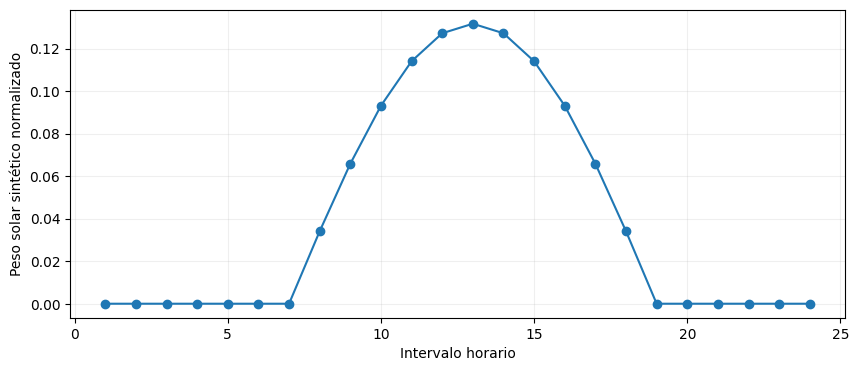

In [4]:
perfil,ind=sector.perfiles_horarios()
peso=np.maximum(0,np.sin(np.pi*(np.arange(24)-6)/12))
captura_sintetica=modelos.precio_captura(perfil.precio_medio_nominal_COP_kWh.to_numpy(),peso)
display(pd.Series({**ind,'captura_con_perfil_solar_sintetico_COP_kWh':captura_sintetica}))
plt.plot(np.arange(1,25),peso/peso.sum(),marker='o');plt.xlabel('Intervalo horario');plt.ylabel('Peso solar sintético normalizado');plt.show()

El perfil decide qué horas pesan más. Desplázalo dos horas y repite para entender la diferencia. Mantener precios fijos hace de esto una ponderación, no una simulación de canibalización ni un ingreso liquidado. El análisis de contratos debe añadir cantidades y obligaciones reales.

## Registrar el avance del equipo
Sustituye el campo de decisión por tu razonamiento y conserva el nivel de evidencia. El identificador es el mismo durante todo el caso.

In [5]:
decision_estudiante='POR COMPLETAR'
expediente.registrar(CASO,'mercado','Universo observado: '+str(len(recursos))+' recursos; captura con perfil sintético: '+str(captura_sintetica),'descripcion' if 3 in [0,1] else 'exploracion',
 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
 'Transformaciones, calendario y unidades explícitos en las celdas precedentes',
 'No constituye evaluación completa del SIN; distinguir cada resultado observado de los sintéticos',
 decision_estudiante)

Out[5]: 
{'version': 2,
 'caso': 'ejemplo_docente',
 'etapas': {'evidencia': {'hallazgo': 'Año 2024: generación 83262.923 GWh y pico 11704.365 MW; son magnitudes diferentes',
   'nivel': 'descripcion',
   'fuente': 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
   'transformacion': 'Transformaciones, calendario y unidades explícitos en las celdas precedentes',
   'limite': 'No constituye evaluación completa del SIN; distinguir cada resultado observado de los sintéticos',
   'decision_estudiante': 'POR COMPLETAR'},
  'identidad': {'hallazgo': "Asociaciones mensuales: {'meses': 264, 'correlacion_bruta': -0.3654022452929349, 'correlacion_residual': -0.5459860648178948, 'interpretacion': 'Asociación; controles aditivos no identifican causalidad ni corrigen toda no estacionariedad'}",
   'nivel': 'descripcion',
   'fuente': 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
   'transformacion': 'Transformaciones, calendario y unidades explícit